# Modeling

This notebook focuses on building and evaluating machine learning models for predicting customer churn.

Three model families are evaluated:

* Logistic Regression (interpretable baseline model)

* Random Forest (non-linear ensemble model)

* XGBoost (gradient boosting model)

Each model uses a slightly different feature configuration defined during the feature engineering stage.

The goal is to compare model performance, interpret key churn drivers, and evaluate which model provides the best balance between predictive performance and interpretability.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/projects/telco-customer-churn


Mounted at /content/drive
/content/drive/MyDrive/projects/telco-customer-churn


## 1. Load feature-engineered dataset


In [2]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import randint
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
    precision_score,
    recall_score,
    accuracy_score
)

In [3]:
X_train = joblib.load("data/X_train.pkl")
X_test = joblib.load("data/X_test.pkl")
y_train = joblib.load("data/y_train.pkl")
y_test = joblib.load("data/y_test.pkl")

In [4]:
core_services = [
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport'
]

## 2. Define feature sets for different model families


Different models may benefit from different feature representations.

For example:

* Logistic Regression benefits from engineered aggregate features and scaled numerical variables.

* Tree-based models handle raw numerical features and feature interactions naturally.


In [5]:
num_features_LR = ['MonthlyCharges', 'TotalCharges', 'ServicesCount_core']
num_features_RF_GB = ['tenure', 'MonthlyCharges', 'TotalCharges']
cat_features_RF_GB = X_train.select_dtypes(exclude = 'number').columns
cat_features_LR = X_train.select_dtypes(exclude = 'number').columns.drop(core_services)

In [6]:
models = {
    'LR': LogisticRegression(class_weight = 'balanced'),
    'RF': RandomForestClassifier(class_weight = 'balanced'),
    'XGB': XGBClassifier()
}

Tree-based models are generally robust to correlated features, therefore both individual services and aggregated service count can be retained without causing instability.

## 3. Preprocessing and modeling pipelines

Separate preprocessing pipelines are created for linear and tree-based models.

In [7]:
def preprocessor(num_features, cat_features):
  return ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(handle_unknown = 'ignore'), cat_features)
  ], remainder='passthrough')


In [8]:
preprocessor_LR = preprocessor(num_features_LR, cat_features_LR)
preprocessor_RF_GB = preprocessor(num_features_RF_GB, cat_features_RF_GB)


In [9]:
pipelines = {}

for model_name, model in models.items():
  if model_name == 'LR':
    pipe = Pipeline([
        (f'preprocess', preprocessor_LR),
        ('model', model)
    ])
  else:
        pipe = Pipeline([
        (f'preprocess', preprocessor_RF_GB),
        ('model', model)
    ])
  pipelines[f'{model_name}'] = pipe

### Hyperparameter search space

In [10]:
param_dist_dict = {}

param_dist_dict['LR'] = {
    'model__C': (0.01, 0.1, 1, 10),
    'model__max_iter': [100, 200, 500, 1000]
}

param_dist_dict['RF'] = {
    'model__n_estimators':     randint(50, 300),
    'model__max_depth':        [None, 3, 5, 7, 10, 15],
    'model__min_samples_leaf': randint(1, 30),
    'model__max_features':     ['sqrt', 'log2', None],
}

param_dist_dict['XGB'] = {
    'model__n_estimators': randint(100, 1000),
    'model__max_depth': randint(3, 10),
    'model__learning_rate': [0.01, 0.05, 0.1, 0.2]
}


### Model training and evaluation

In [11]:
results = {}

for name in models:

  search = RandomizedSearchCV(
      pipelines[name],
      param_dist_dict[name],
      n_iter=20,
      scoring="roc_auc",
      cv=5,
      n_jobs=-1
  )
  if name == 'LR':
    search.fit(X_train.drop(columns = core_services, axis = 1), y_train)
  else:
    search.fit(X_train, y_train)

  best_model = search.best_estimator_

  y_pred = best_model.predict(X_test)
  y_prob = best_model.predict_proba(X_test)[:,1]
  y_prob_train = best_model.predict_proba(X_train)[:,1]
  best_idx = search.best_index_
  results[name] = {
      "best_model": best_model,
      "best_params": search.best_params_,
      "CV_score": round(search.best_score_, 3),
      "CV_score_std": round(search.cv_results_['std_test_score'][best_idx], 3),
      "roc_auc_train": round(roc_auc_score(y_train, y_prob_train), 3),
      "roc_auc_test": round(roc_auc_score(y_test, y_prob), 3),
      "precision": round(precision_score(y_test, y_pred), 3),
      "recall": round(recall_score(y_test, y_pred), 3),
      "accuracy": round(accuracy_score(y_test, y_pred), 3)
  }


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 16 is smaller than n_iter=20. Running 16 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


## 4. Logistic Regression

Logistic Regression provides an interpretable baseline model that allows direct interpretation of feature effects.

              precision    recall  f1-score   support

           0       0.92      0.74      0.82      1294
           1       0.53      0.83      0.65       467

    accuracy                           0.76      1761
   macro avg       0.73      0.78      0.73      1761
weighted avg       0.82      0.76      0.77      1761



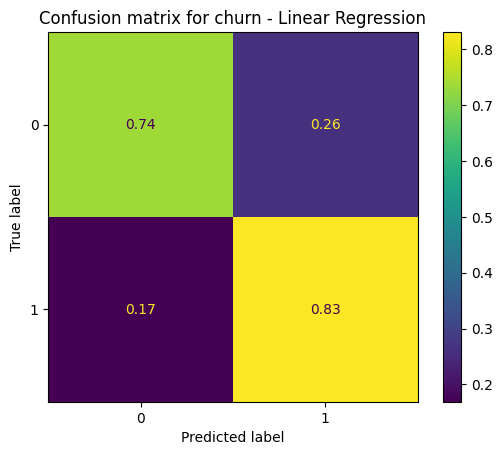

In [12]:
disp = ConfusionMatrixDisplay(confusion_matrix(y_test, results['LR']['best_model'].predict(X_test), normalize='true'))
print(classification_report(y_test, results['LR']['best_model'].predict(X_test)))
disp.plot()
plt.title('Confusion matrix for churn - Linear Regression')
plt.show()


### Interpretation of Logistic Regression model results

Logistic Regression identifies most churners but at the cost of many false positives.

* Recall (churn) = 0.82

* Precision (churn) = 0.53

* Accuracy = 0.76

Model correctly identifies 82% of customers who will churn.


Only 53% of predicted churners actually churn, meaning many customers are incorrectly flagged as churn risk.


Interpretation:

The model is aggressive in predicting churn, which leads to higher recall but lower precision.
This could be useful in scenarios where missing a churner is more costly than targeting some customers unnecessarily (e.g., retention campaigns).

### Coefficient interpretation

In [13]:
def interpret_row(row):

    if row['coef'] > 0:
        return f"Feature '{row['feature']}' increases churn odds by {row['odds']:.2f}x"

    else:
        decrease = 1 - row['odds']
        return f"Feature '{row['feature']}' decreases churn odds by {decrease:.0%}"

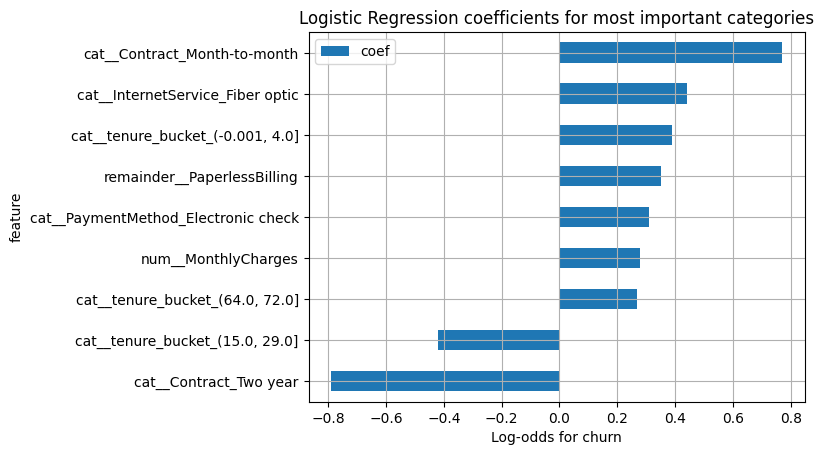

In [14]:
threshold = 0.25

coef = results['LR']['best_model'].named_steps['model'].coef_[0].round(2)
feature_names = results['LR']['best_model'].named_steps['preprocess'].get_feature_names_out()
odds = np.exp(coef).round(2)
coef_df = pd.DataFrame({
    "feature": feature_names,
    "coef": coef,
    "odds" : odds,
})
coef_df["interpretation"] = coef_df.apply(interpret_row, axis = 1)

coef_df_limited = coef_df.query('abs(coef) > @threshold').sort_values("coef")

coef_df_limited.plot(kind="barh", x="feature", y="coef")
plt.title("Logistic Regression coefficients for most important categories")
plt.xlabel('Log-odds for churn')
plt.grid()
plt.show()


In [15]:
coef_df_limited

,feature,coef,odds,interpretation
17,cat__Contract_Two year,-0.79,0.45,Feature 'cat__Contract_Two year' decreases chu...
24,"cat__tenure_bucket_(15.0, 29.0]",-0.42,0.66,"Feature 'cat__tenure_bucket_(15.0, 29.0]' decr..."
27,"cat__tenure_bucket_(64.0, 72.0]",0.27,1.31,"Feature 'cat__tenure_bucket_(64.0, 72.0]' incr..."
0,num__MonthlyCharges,0.28,1.32,Feature 'num__MonthlyCharges' increases churn ...
20,cat__PaymentMethod_Electronic check,0.31,1.36,Feature 'cat__PaymentMethod_Electronic check' ...
34,remainder__PaperlessBilling,0.35,1.42,Feature 'remainder__PaperlessBilling' increase...
22,"cat__tenure_bucket_(-0.001, 4.0]",0.39,1.48,"Feature 'cat__tenure_bucket_(-0.001, 4.0]' inc..."
7,cat__InternetService_Fiber optic,0.44,1.55,Feature 'cat__InternetService_Fiber optic' inc...
15,cat__Contract_Month-to-month,0.77,2.16,Feature 'cat__Contract_Month-to-month' increas...


## 5. Random Forest

Random Forest allows modeling non-linear relationships and complex feature interactions.

              precision    recall  f1-score   support

           0       0.92      0.77      0.84      1294
           1       0.56      0.82      0.66       467

    accuracy                           0.78      1761
   macro avg       0.74      0.79      0.75      1761
weighted avg       0.82      0.78      0.79      1761



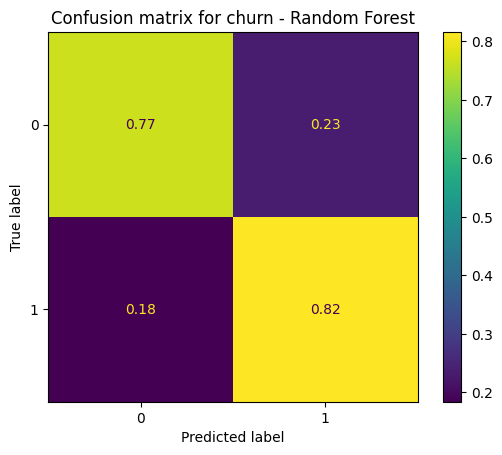

In [16]:
print(classification_report(y_test, results['RF']['best_model'].predict(X_test)))
cm = confusion_matrix(y_test, results['RF']['best_model'].predict(X_test),normalize = 'true')
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.title('Confusion matrix for churn - Random Forest')
plt.show()

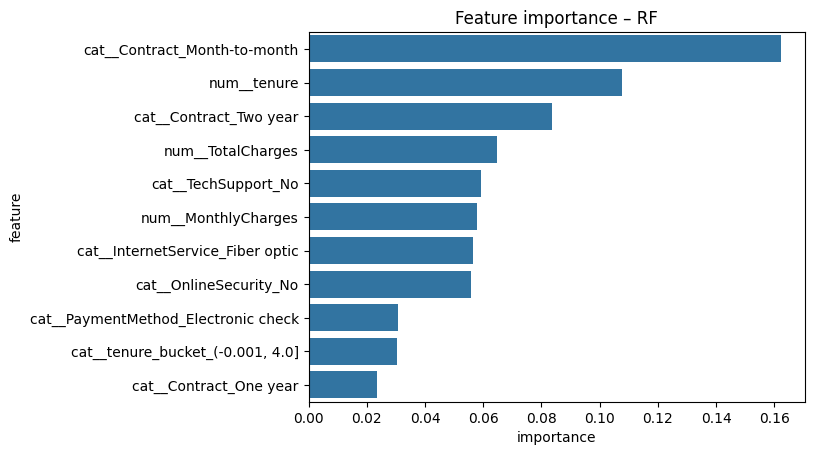

In [17]:
feature_importance_rf = results['RF']['best_model'].named_steps['model'].feature_importances_
feature_names_rf = results['RF']['best_model'].named_steps['preprocess'].get_feature_names_out()
feat_imp_df = pd.DataFrame({
    'feature': feature_names_rf,
    'importance': feature_importance_rf
}).sort_values(by='importance', ascending=False)

threshold = 0.02
feat_imp_df_limited = feat_imp_df.query('abs(importance) > @threshold')
sns.barplot(data=feat_imp_df_limited, x='importance', y='feature')
plt.title("Feature importance – RF")
plt.show()


### Interpretation of Random Forest model results

Random Forest slightly improves overall performance while maintaining strong churn detection.

Recall (churn) = 0.81  
Precision (churn) = 0.57  
Accuracy = 0.79  

The model correctly identifies 81% of customers who churn.

About 57% of customers flagged as churn risk actually churn.

This means the model detects churners almost as well as Logistic Regression, but produces fewer false positives, making it a more balanced solution.


## 6. XGBoost

XGBoost is a gradient boosting model known for strong predictive performance on structured datasets.

              precision    recall  f1-score   support

           0       0.84      0.93      0.88      1294
           1       0.72      0.49      0.59       467

    accuracy                           0.81      1761
   macro avg       0.78      0.71      0.73      1761
weighted avg       0.80      0.81      0.80      1761



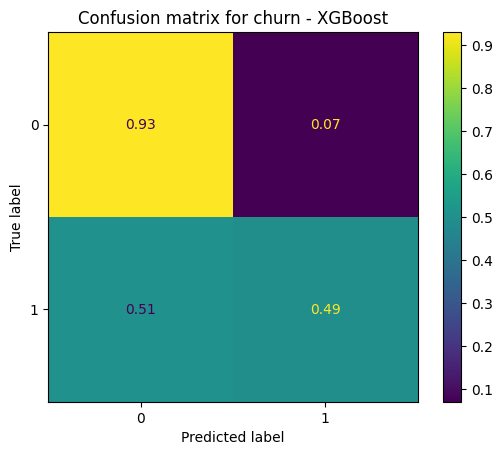

In [18]:
print(classification_report(y_test,  results['XGB']['best_model'].predict(X_test)))
cm = confusion_matrix(y_test, results['XGB']['best_model'].predict(X_test),normalize = 'true')
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.title('Confusion matrix for churn - XGBoost')
plt.show()

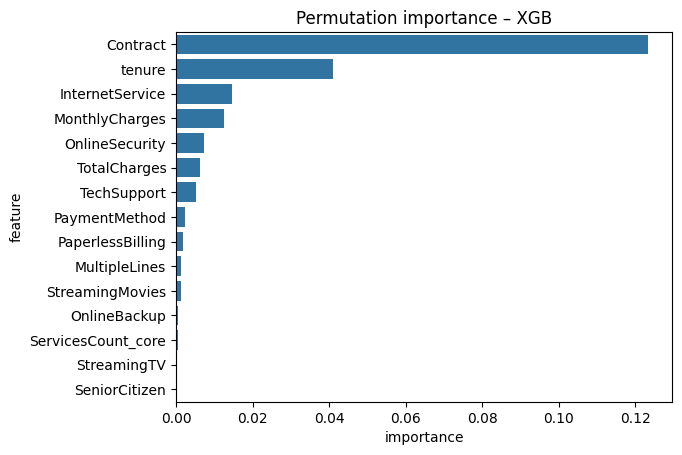

In [19]:
XGB = results["XGB"]["best_model"]

perm_imp = permutation_importance(
    XGB, X_test, y_test,
    n_repeats=20,
    random_state=42,
    scoring='roc_auc'
)
feature_names_xgb = X_test.columns

perm_df = pd.DataFrame({
    'feature': feature_names_xgb,
    'importance': perm_imp.importances_mean
}).sort_values(by='importance', ascending=False)
perm_df_head = perm_df.head(15)
sns.barplot(data=perm_df_head, x='importance', y='feature')
plt.title("Permutation importance – XGB")
plt.show()

In [20]:
perm_df

,feature,importance
14,Contract,0.123372
4,tenure,0.040925
7,InternetService,0.014585
17,MonthlyCharges,0.012581
8,OnlineSecurity,0.007260
18,TotalCharges,0.006279
11,TechSupport,0.005340
16,PaymentMethod,0.002276
15,PaperlessBilling,0.001782
6,MultipleLines,0.001416


### Interpretation of XGBoost model results

XGBoost achieves the highest overall accuracy, but performs worse in detecting churners.

* Recall (churn) = 0.50

* Precision (churn) = 0.71

* Accuracy = 0.81

The model is conservative when predicting churn, which means that when it predicts churn, it is usually correct (high precision).
However, it misses about half of churners (low recall).

This type of model may be useful if retention actions are expensive, and the company prefers to target only the highest-risk customers.

## 7. Model Comparison


In [141]:
def plot_roc_curves(models, X_set, y_set):
  plt.plot([0,1], [0,1], linestyle = '--', label = "Random")

  for name, model in models.items():
    y_prob = model.predict_proba(X_set)[:,1]

    fpr, tpr, _ = roc_curve(y_set, y_prob)
    auc = roc_auc_score(y_set, y_prob)

    plt.plot(fpr, tpr, lw = 2, label = f'{name} (AUC = {auc:.3f})')

  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title(' ROC Curve Comparison')
  plt.legend()
  plt.grid()
  plt.show()

In [22]:
results_df = pd.DataFrame(results).T

results_df = results_df.drop(columns='best_model')

results_df.sort_values("roc_auc_test", ascending=False)

,best_params,CV_score,CV_score_std,roc_auc_train,roc_auc_test,precision,recall,accuracy
XGB,"{'model__learning_rate': 0.01, 'model__max_dep...",0.844,0.003,0.868,0.862,0.717,0.495,0.814
RF,"{'model__max_depth': None, 'model__max_feature...",0.843,0.002,0.878,0.861,0.559,0.816,0.781
LR,"{'model__max_iter': 500, 'model__C': 0.1}",0.843,0.004,0.847,0.86,0.532,0.831,0.761


All three models achieved very similar predictive performance.

None of the models shows clear signs of overfitting, as the training and test ROC-AUC scores remain relatively close.

Given the comparable performance, Logistic Regression may be preferred due to its strong interpretability and ease of explaining model decisions.

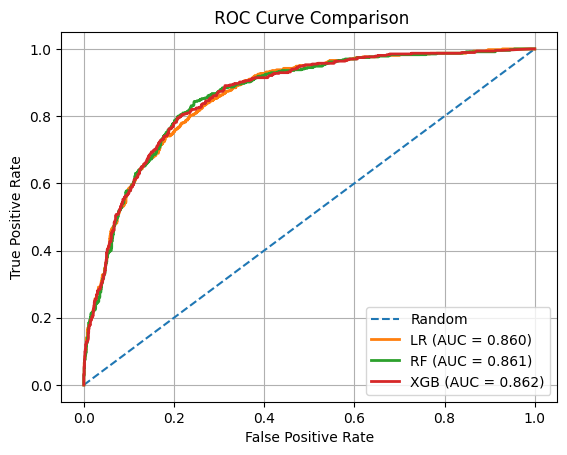

In [142]:
plot_roc_curves({'LR': results['LR']['best_model'], 'RF': results['RF']['best_model'],'XGB': results['XGB']['best_model']}, X_test, y_test)


ROC curves for all models are very close to each other, confirming the similarity in predictive performance.

### Overall comparison

In [24]:
overall_comparison = pd.DataFrame({
    'Model': ['LR', 'RF', 'XGB'],
    'Strenght': ['detects most churners','best balance', 'highest accuracy'],
    'Weakness': ['many false positives', 'slightly less interpretable', 'misses many churners']
})
overall_comparison

,Model,Strenght,Weakness
0,LR,detects most churners,many false positives
1,RF,best balance,slightly less interpretable
2,XGB,highest accuracy,misses many churners


If the business goal is maximizing churn detection, Logistic Regression or Random Forest may be preferable.

If the goal is targeting only the highest-risk customers, XGBoost may be more suitable due to higher precision.

Given that model performance is relatively similar, Logistic Regression may still be attractive due to its high interpretability and transparency, which is often valuable for business stakeholders.

## 8. Business Insights

The strongest predictor of churn across all models is contract structure. Customers on month-to-month contracts exhibit significantly higher churn probability compared to customers with long-term agreements.

Customer tenure also plays an important role. Newly acquired customers are substantially more likely to churn, indicating that the first months of the customer lifecycle represent a critical retention period.

Internet service is also a strong predictor. Customers using fiber optic service show noticeably higher churn probability, which may indicate pricing sensitivity or stronger market competition in this segment.

Billing behavior also appears to matter. Customers paying via electronic check exhibit elevated churn risk compared to customers using automatic payment methods.

Service bundling shows a moderate but consistent effect on churn. When individual service variables were removed from the Logistic Regression model and replaced with a single aggregated feature (ServicesCount_core), the coefficient became more pronounced. Each additional core service reduces churn odds by approximately 21%. However, tree-based models suggest that the impact of bundling is weaker compared to structural factors such as contract length and pricing.

Overall, the results suggest that churn is driven primarily by contract commitment and customer lifecycle stage, while additional services play a secondary role in retention.

## 9. Profit curve

A profit curve was used to determine the optimal classification threshold.

The default threshold (0.5) does not maximize business value because churn prediction involves asymmetric costs.

In this simplified scenario, saving a customer generates a value of 1000 units, while running a retention campaign costs 100 units.

In [125]:
model = results['RF']['best_model']

y_prob = model.predict_proba(X_test)[:,1]

thresholds = np.unique(y_prob)

customer_value = 1000
campaign_cost = 100

profits = []

for t in thresholds:

    y_pred = (y_prob >= t).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    profit = (
        tp * (customer_value - campaign_cost)
        - fp * campaign_cost
        - fn * customer_value
    )

    profits.append(profit)

profit_df = pd.DataFrame({
    "threshold": thresholds,
    "profit": profits
})

best_profit_row = profit_df.loc[profit_df["profit"].idxmax()]
best_profit_threshold = best_profit_row["threshold"]
best_profit = best_profit_row["profit"]

default_profit_row = profit_df.query("threshold >= 0.5").iloc[0]
default_profit_threshold = default_profit_row["threshold"]
default_profit = default_profit_row["profit"]

profit_diff = best_profit - default_profit

print("Default profit:", round(default_profit,3))
print("Best threshold:", round(best_profit_threshold,3))
print("Maximum profit:", int(best_profit))

print("Profit difference after threshold adjustment:", round(profit_diff,2))


Default profit: 226900.0
Best threshold: 0.196
Maximum profit: 319100
Profit difference after threshold adjustment: 92200.0


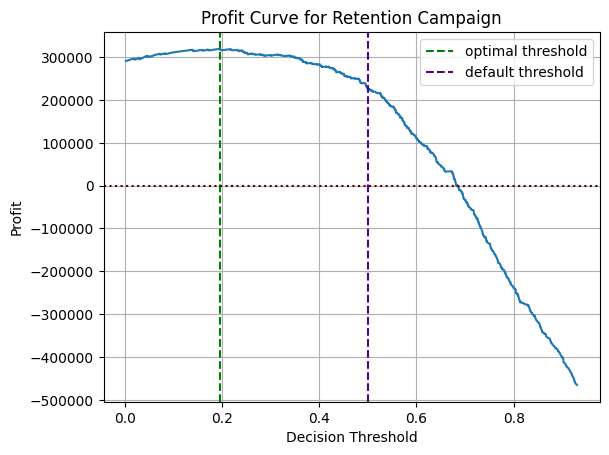

In [140]:
plt.plot(profit_df["threshold"], profit_df["profit"])
plt.axvline(best_profit_threshold, linestyle="--", color = '#008000', label="optimal threshold")
plt.axvline(default_profit_threshold, linestyle = "--", color = '#500090', label="default threshold")
plt.axhline(0, linestyle=":", color = '#500000')
plt.legend()
plt.xlabel("Decision Threshold")
plt.ylabel("Profit")
plt.title("Profit Curve for Retention Campaign")
plt.grid()
plt.savefig("figures/profit_curve.png", dpi=300, bbox_inches="tight")
plt.show()



The profit curve shows that the optimal classification threshold is around 0.20, which differs from the default value of 0.5. This means that customers with a predicted churn probability above 19.6% should be targeted with retention campaigns.

The lower threshold is justified by the business cost structure: the cost of losing a customer is much higher than the cost of running a retention campaign.

Adjusting the decision threshold increased the expected profit by 94,500 units compared to using the default threshold.

This result highlights that the optimal decision rule in churn prediction depends on the business cost structure rather than purely statistical model performance.